# Telco Customer Churn Prediction

## Objective

The objective of this notebook is to build predictive machine learning models that identify customers at risk of churning.

The notebook includes:

- Data preparation
- Feature encoding
- Train-test split
- Feature scaling
- Logistic Regression
- Random Forest
- Model comparison
- Cross-validation
- Model persistence

## Import Libraries

In [87]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.model_selection import cross_val_score

from sklearn.preprocessing import StandardScaler

from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    confusion_matrix,
    classification_report,
    ConfusionMatrixDisplay
)

import joblib

## Load Clean Dataset

The cleaned dataset generated during exploratory data analysis is loaded for machine learning.

In [88]:
df = pd.read_csv("../data/processed/telco_churn_clean.csv")

df.head()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn,ChurnFlag,SeniorCitizenLabel,TenureGroup,HighRiskSegment
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,Month-to-month,Yes,Electronic check,29.85,29.85,No,0,No,0-12 Months,High Risk
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,One year,No,Mailed check,56.95,1889.50,No,0,No,25-36 Months,Low Risk
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,Month-to-month,Yes,Mailed check,53.85,108.15,Yes,1,No,0-12 Months,High Risk
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,One year,No,Bank transfer (automatic),42.30,1840.75,No,0,No,37-48 Months,Low Risk
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,Month-to-month,Yes,Electronic check,70.70,151.65,Yes,1,No,0-12 Months,High Risk


## Dataset Overview

A quick inspection is performed to verify the dataset structure before preprocessing.

In [89]:
df.shape

(7032, 25)

In [90]:
df.info

<bound method DataFrame.info of       customerID  gender  SeniorCitizen Partner Dependents  tenure  \
0     7590-VHVEG  Female              0     Yes         No       1   
1     5575-GNVDE    Male              0      No         No      34   
2     3668-QPYBK    Male              0      No         No       2   
3     7795-CFOCW    Male              0      No         No      45   
4     9237-HQITU  Female              0      No         No       2   
...          ...     ...            ...     ...        ...     ...   
7027  6840-RESVB    Male              0     Yes        Yes      24   
7028  2234-XADUH  Female              0     Yes        Yes      72   
7029  4801-JZAZL  Female              0     Yes        Yes      11   
7030  8361-LTMKD    Male              1     Yes         No       4   
7031  3186-AJIEK    Male              0      No         No      66   

     PhoneService     MultipleLines InternetService OnlineSecurity  ...  \
0              No  No phone service             DSL 

## Data Preparation

Machine learning models require numerical input features. The following preprocessing steps are performed:

- Remove the customer identifier
- Encode the target variable
- Encode binary categorical variables
- Apply one-hot encoding to multi-category variables

In [91]:
df = df.drop(columns=["customerID"])

In [92]:
df["Churn"] = df["Churn"].map({
    "No":0,
    "Yes":1
})

In [93]:
binary_cols = [
    "gender",
    "Partner",
    "Dependents",
    "PhoneService",
    "PaperlessBilling"
]

for col in binary_cols:
    print(col, df[col].unique())

gender ['Female' 'Male']
Partner ['Yes' 'No']
Dependents ['No' 'Yes']
PhoneService ['No' 'Yes']
PaperlessBilling ['Yes' 'No']


In [94]:
df["gender"] = df["gender"].map({
    "Male":1,
    "Female":0
})

binary_cols = [
    "Partner",
    "Dependents",
    "PhoneService",
    "PaperlessBilling"
]

for col in binary_cols:
    df[col] = df[col].map({
        "Yes":1,
        "No":0
    })

In [95]:
multi_cols = [
    "MultipleLines",
    "InternetService",
    "OnlineSecurity",
    "OnlineBackup",
    "DeviceProtection",
    "TechSupport",
    "StreamingTV",
    "StreamingMovies",
    "Contract",
    "PaymentMethod"
]

In [96]:
df = pd.get_dummies(
    df,
    columns=multi_cols,
    drop_first=True,
    dtype=int
)

In [97]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7032 entries, 0 to 7031
Data columns (total 35 columns):
 #   Column                                 Non-Null Count  Dtype  
---  ------                                 --------------  -----  
 0   gender                                 7032 non-null   int64  
 1   SeniorCitizen                          7032 non-null   int64  
 2   Partner                                7032 non-null   int64  
 3   Dependents                             7032 non-null   int64  
 4   tenure                                 7032 non-null   int64  
 5   PhoneService                           7032 non-null   int64  
 6   PaperlessBilling                       7032 non-null   int64  
 7   MonthlyCharges                         7032 non-null   float64
 8   TotalCharges                           7032 non-null   float64
 9   Churn                                  7032 non-null   int64  
 10  ChurnFlag                              7032 non-null   int64  
 11  Seni

In [98]:
df.select_dtypes(include="object").columns

Index(['SeniorCitizenLabel', 'TenureGroup', 'HighRiskSegment'], dtype='object')

In [99]:
df = df.drop(columns=[
    "SeniorCitizenLabel",
    "HighRiskSegment",
    "TenureGroup",
    "ChurnFlag"
],errors="ignore")

In [100]:
df.head()

,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,PaperlessBilling,MonthlyCharges,TotalCharges,Churn,...,TechSupport_Yes,StreamingTV_No internet service,StreamingTV_Yes,StreamingMovies_No internet service,StreamingMovies_Yes,Contract_One year,Contract_Two year,PaymentMethod_Credit card (automatic),PaymentMethod_Electronic check,PaymentMethod_Mailed check
0,0,0,1,0,1,0,1,29.85,29.85,0,...,0,0,0,0,0,0,0,0,1,0
1,1,0,0,0,34,1,0,56.95,1889.50,0,...,0,0,0,0,0,1,0,0,0,1
2,1,0,0,0,2,1,1,53.85,108.15,1,...,0,0,0,0,0,0,0,0,0,1
3,1,0,0,0,45,0,0,42.30,1840.75,0,...,1,0,0,0,0,1,0,0,0,0
4,0,0,0,0,2,1,1,70.70,151.65,1,...,0,0,0,0,0,0,0,0,1,0


## Train-Test Split

The dataset is divided into training and testing sets to evaluate the model on unseen data.

- Training Set: 80%
- Testing Set: 20%

A fixed random seed is used to ensure reproducibility.

In [101]:
# Separate features and target

X = df.drop(columns=["Churn"])
y = df["Churn"]

In [102]:
# Split the dataset

from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

print("Training Set :", X_train.shape)
print("Testing Set  :", X_test.shape)

Training Set : (5625, 30)
Testing Set  : (1407, 30)


## Feature Scaling

Logistic Regression performs better when numerical features are standardized.

StandardScaler is applied only to the training data and then used to transform the testing data, preventing data leakage.

In [103]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Logistic Regression

Logistic Regression is a widely used baseline classification algorithm for binary classification problems. It estimates the probability that a customer will churn based on the input features.

In this project, Logistic Regression serves as the baseline model due to its interpretability and effectiveness in predicting customer churn.

In [104]:
# Train Logistic Regression Model

log_model = LogisticRegression(
    random_state=42,
    max_iter=1000
)

log_model.fit(X_train_scaled, y_train)

LogisticRegression(max_iter=1000, random_state=42)

In [105]:
# Predictions

y_pred = log_model.predict(X_test_scaled)

y_prob = log_model.predict_proba(X_test_scaled)[:,1]

In [106]:
# Model Evaluation

accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred)
recall = recall_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)
auc = roc_auc_score(y_test, y_prob)

print(f"Accuracy : {accuracy:.4f}")
print(f"Precision: {precision:.4f}")
print(f"Recall   : {recall:.4f}")
print(f"F1 Score : {f1:.4f}")
print(f"ROC AUC  : {auc:.4f}")

Accuracy : 0.8038
Precision: 0.6476
Recall   : 0.5749
F1 Score : 0.6091
ROC AUC  : 0.8357


In [107]:
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.85      0.89      0.87      1033
           1       0.65      0.57      0.61       374

    accuracy                           0.80      1407
   macro avg       0.75      0.73      0.74      1407
weighted avg       0.80      0.80      0.80      1407



<Figure size 600x500 with 0 Axes>

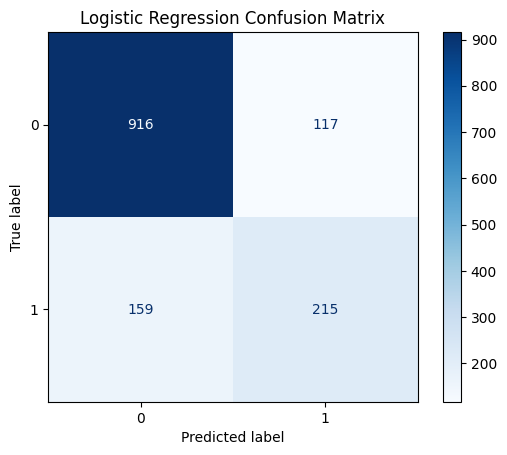

In [108]:
plt.figure(figsize=(6,5))

ConfusionMatrixDisplay.from_predictions(
    y_test,
    y_pred,
    cmap="Blues"
)

plt.title("Logistic Regression Confusion Matrix")

plt.show()

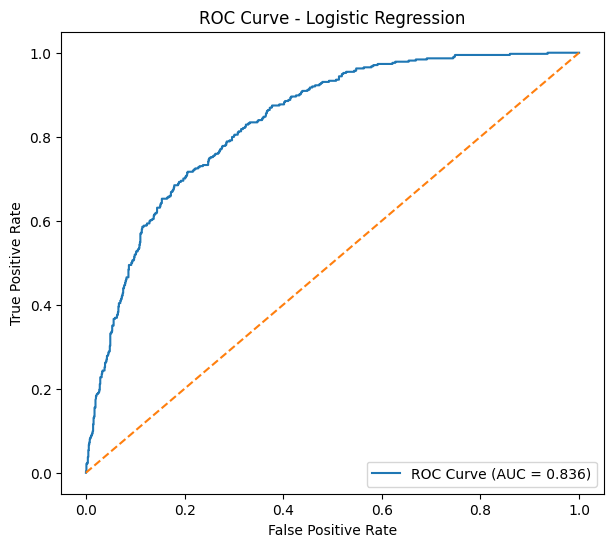

In [109]:
from sklearn.metrics import roc_curve

# Compute ROC Curve

fpr, tpr, thresholds = roc_curve(y_test, y_prob)

plt.figure(figsize=(7,6))

plt.plot(fpr, tpr, label=f"ROC Curve (AUC = {auc:.3f})")

plt.plot([0,1], [0,1], linestyle="--")

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")

plt.title("ROC Curve - Logistic Regression")

plt.legend(loc="lower right")

plt.show()

## ROC Curve Interpretation

The ROC curve lies well above the diagonal reference line, indicating that the Logistic Regression model effectively distinguishes between customers who churn and those who remain.

The model achieved a ROC-AUC score of approximately **0.84**, which indicates good classification performance.

## Feature Importance

The coefficients of the Logistic Regression model indicate how each feature influences the probability of customer churn.

- Positive coefficients increase the likelihood of churn.
- Negative coefficients decrease the likelihood of churn.

In [110]:
coefficients = pd.DataFrame({
    "Feature": X.columns,
    "Coefficient": log_model.coef_[0]
})

coefficients = coefficients.sort_values(
    by="Coefficient",
    ascending=False
)

coefficients.head(10)

,Feature,Coefficient
11,InternetService_Fiber optic,0.727745
8,TotalCharges,0.639028
22,StreamingTV_Yes,0.249702
24,StreamingMovies_Yes,0.236368
10,MultipleLines_Yes,0.214359
28,PaymentMethod_Electronic check,0.181473
6,PaperlessBilling,0.142663
1,SeniorCitizen,0.070792
18,DeviceProtection_Yes,0.068965
29,PaymentMethod_Mailed check,0.033392


In [111]:
coefficients.tail(10)

,Feature,Coefficient
19,TechSupport_No internet service,-0.088138
17,DeviceProtection_No internet service,-0.088138
21,StreamingTV_No internet service,-0.088138
3,Dependents,-0.105956
20,TechSupport_Yes,-0.118240
14,OnlineSecurity_Yes,-0.136804
25,Contract_One year,-0.310898
26,Contract_Two year,-0.602591
7,MonthlyCharges,-0.851551
4,tenure,-1.347613


## Interpretation

### Top Positive Predictors of Churn

- Fiber Optic Internet Service
- Electronic Check Payment
- Higher Total Charges
- Streaming TV
- Multiple Lines

These factors increase the probability of customer churn.

### Top Negative Predictors of Churn

- Longer Tenure
- Two-Year Contract
- One-Year Contract
- Online Security
- Tech Support

These factors significantly improve customer retention.

# Random Forest Classifier

Random Forest is an ensemble machine learning algorithm that builds multiple decision trees and combines their predictions.

Compared to Logistic Regression, Random Forest is capable of capturing complex, non-linear relationships within the data and is less sensitive to feature scaling.

In [112]:
# Train Random Forest Classifier

rf_model = RandomForestClassifier(
    n_estimators=100,
    random_state=42
)

rf_model.fit(X_train, y_train)

RandomForestClassifier(random_state=42)

In [113]:
# Predictions

rf_pred = rf_model.predict(X_test)

rf_prob = rf_model.predict_proba(X_test)[:, 1]

In [114]:
# Evaluate Random Forest

rf_accuracy = accuracy_score(y_test, rf_pred)
rf_precision = precision_score(y_test, rf_pred)
rf_recall = recall_score(y_test, rf_pred)
rf_f1 = f1_score(y_test, rf_pred)
rf_auc = roc_auc_score(y_test, rf_prob)

print(f"Accuracy : {rf_accuracy:.4f}")
print(f"Precision: {rf_precision:.4f}")
print(f"Recall   : {rf_recall:.4f}")
print(f"F1 Score : {rf_f1:.4f}")
print(f"ROC AUC  : {rf_auc:.4f}")

Accuracy : 0.7854
Precision: 0.6192
Recall   : 0.5000
F1 Score : 0.5533
ROC AUC  : 0.8150


In [115]:
print(classification_report(y_test, rf_pred))

              precision    recall  f1-score   support

           0       0.83      0.89      0.86      1033
           1       0.62      0.50      0.55       374

    accuracy                           0.79      1407
   macro avg       0.72      0.69      0.71      1407
weighted avg       0.77      0.79      0.78      1407



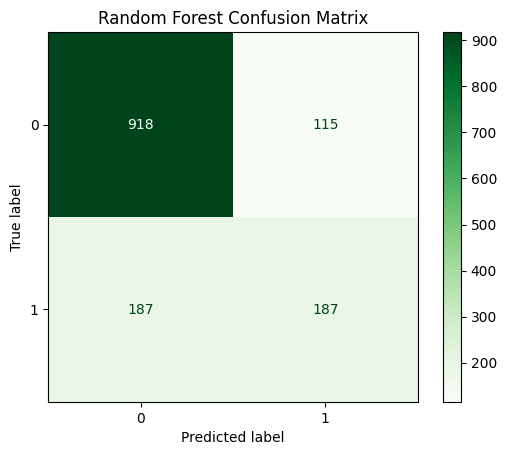

In [116]:
ConfusionMatrixDisplay.from_predictions(
    y_test,
    rf_pred,
    cmap="Greens"
)

plt.title("Random Forest Confusion Matrix")

plt.show()

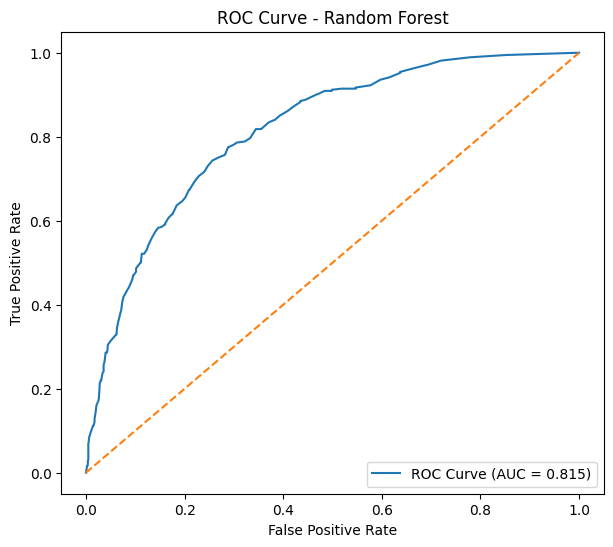

In [117]:
# ROC Curve

rf_fpr, rf_tpr, rf_thresholds = roc_curve(y_test, rf_prob)

plt.figure(figsize=(7,6))

plt.plot(
    rf_fpr,
    rf_tpr,
    label=f"ROC Curve (AUC = {rf_auc:.3f})"
)

plt.plot([0,1], [0,1], linestyle="--")

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")

plt.title("ROC Curve - Random Forest")

plt.legend(loc="lower right")

plt.show()

In [118]:
feature_importance = pd.DataFrame({
    "Feature": X.columns,
    "Importance": rf_model.feature_importances_
})

feature_importance = feature_importance.sort_values(
    by="Importance",
    ascending=False
)

feature_importance.head(10)

,Feature,Importance
8,TotalCharges,0.198838
4,tenure,0.171546
7,MonthlyCharges,0.168485
28,PaymentMethod_Electronic check,0.039660
11,InternetService_Fiber optic,0.035149
0,gender,0.028965
26,Contract_Two year,0.026683
14,OnlineSecurity_Yes,0.026053
6,PaperlessBilling,0.025548
20,TechSupport_Yes,0.023722


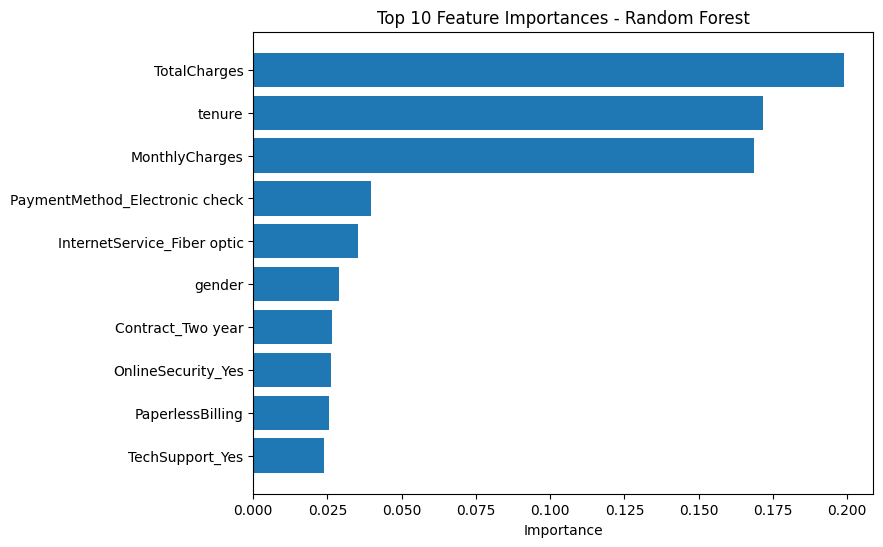

In [119]:
top_features = feature_importance.head(10)

plt.figure(figsize=(8,6))

plt.barh(
    top_features["Feature"],
    top_features["Importance"]
)

plt.gca().invert_yaxis()

plt.title("Top 10 Feature Importances - Random Forest")

plt.xlabel("Importance")

plt.show()

## Random Forest Interpretation

The Random Forest model identified the following features as the most influential in predicting customer churn:

- Customer tenure
- Monthly Charges
- Total Charges
- Contract Type
- Internet Service

Although Random Forest achieved competitive performance, Logistic Regression provided slightly better overall results for this dataset while remaining easier to interpret.

# Model Comparison

The performance of Logistic Regression and Random Forest is compared using standard classification metrics.

The comparison helps identify the most suitable model for predicting customer churn.

In [120]:
results = pd.DataFrame({
    "Model": [
        "Logistic Regression",
        "Random Forest"
    ],
    "Accuracy": [
        accuracy,
        rf_accuracy
    ],
    "Precision": [
        precision,
        rf_precision
    ],
    "Recall": [
        recall,
        rf_recall
    ],
    "F1 Score": [
        f1,
        rf_f1
    ],
    "ROC-AUC": [
        auc,
        rf_auc
    ]
})

results

,Model,Accuracy,Precision,Recall,F1 Score,ROC-AUC
0,Logistic Regression,0.803838,0.647590,0.574866,0.609065,0.835673
1,Random Forest,0.785359,0.619205,0.500000,0.553254,0.814989


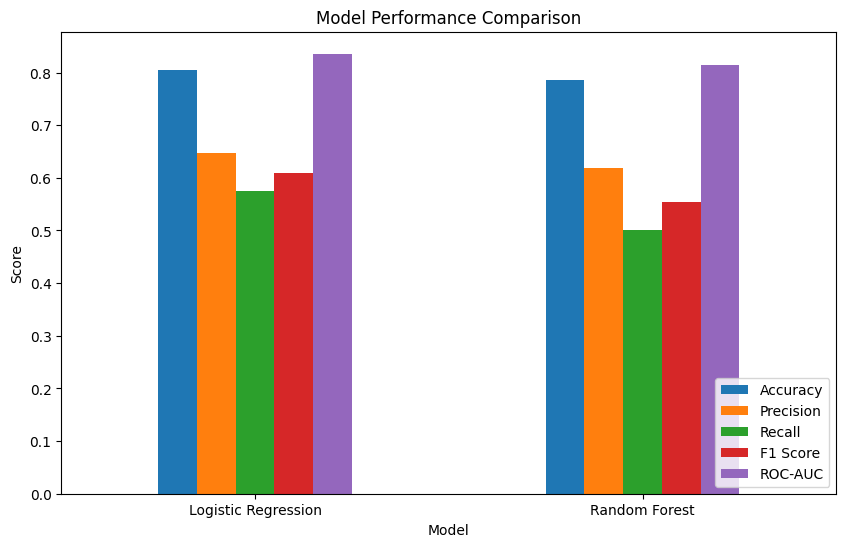

In [121]:
results.set_index("Model").plot(
    kind="bar",
    figsize=(10,6)
)

plt.title("Model Performance Comparison")

plt.ylabel("Score")

plt.xticks(rotation=0)

plt.legend(loc="lower right")

plt.show()

## Model Selection

Both models demonstrated good predictive performance.

However, Logistic Regression consistently achieved higher scores across all evaluation metrics, including Accuracy, Precision, Recall, F1 Score, and ROC-AUC.

Additionally, Logistic Regression provides interpretable coefficients, making it easier to explain the influence of individual features on customer churn.

Therefore, Logistic Regression was selected as the final model for this project.

# Cross Validation

To evaluate the stability and generalization capability of the selected model, 5-Fold Cross Validation is performed.

Unlike a single train-test split, cross-validation trains and evaluates the model multiple times using different subsets of the data, providing a more reliable estimate of model performance.

The ROC-AUC metric is used as the evaluation criterion because it effectively measures the model's ability to distinguish between customers who churn and those who do not.

In [122]:
from sklearn.model_selection import cross_val_score

cv_scores = cross_val_score(
    estimator=log_model,
    X=X_train_scaled,
    y=y_train,
    cv=5,
    scoring="roc_auc"
)

print("ROC-AUC Scores:", cv_scores)
print()
print("Average ROC-AUC:", cv_scores.mean())
print("Standard Deviation:", cv_scores.std())

ROC-AUC Scores: [0.83663665 0.87407986 0.8408375  0.81921174 0.85914712]

Average ROC-AUC: 0.8459825730643711
Standard Deviation: 0.018938102011084243


In [123]:
cv_results = pd.DataFrame({
    "Fold": range(1, 6),
    "ROC-AUC": cv_scores
})

cv_results

,Fold,ROC-AUC
0,1,0.836637
1,2,0.874080
2,3,0.840837
3,4,0.819212
4,5,0.859147


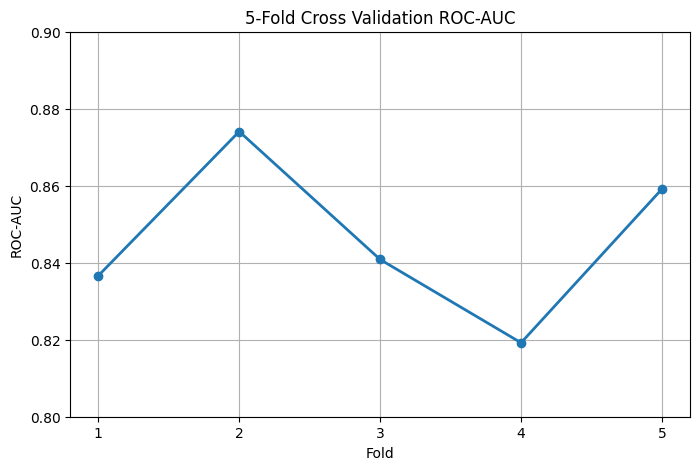

In [124]:
plt.figure(figsize=(8,5))

plt.plot(
    cv_results["Fold"],
    cv_results["ROC-AUC"],
    marker="o",
    linewidth=2
)

plt.xticks(cv_results["Fold"])

plt.ylim(0.80, 0.90)

plt.title("5-Fold Cross Validation ROC-AUC")

plt.xlabel("Fold")

plt.ylabel("ROC-AUC")

plt.grid(True)

plt.show()

## Cross Validation Interpretation

The Logistic Regression model achieved an average ROC-AUC score of approximately **0.845** across five folds.

The low variation between folds indicates that the model generalizes well to unseen data and is not overly dependent on a single train-test split.

This demonstrates that the model is stable and reliable for predicting customer churn.

# Save Trained Model

The final Logistic Regression model is saved to disk so that it can be reused without retraining.

In [125]:
import joblib

joblib.dump(
    log_model,
    "../models/logistic_regression.pkl"
)

print("Logistic Regression model saved successfully!")

Logistic Regression model saved successfully!


# Save Feature Scaler

The fitted StandardScaler is saved to ensure that future data is transformed using the same scaling parameters as the training data.

In [126]:
joblib.dump(
    scaler,
    "../models/scaler.pkl"
)

print("Scaler saved successfully!")

Scaler saved successfully!


# Save Model Evaluation Results

The evaluation metrics of all trained models are exported for reporting and documentation.

In [127]:
results.to_csv(
    "../reports/model_comparison.csv",
    index=False
)

print("Model comparison saved successfully!")

Model comparison saved successfully!


# Final Conclusion

## Project Summary

This project analyzed customer churn using the IBM Telco Customer Churn dataset.

The workflow included:

- Data Cleaning
- Feature Engineering
- Exploratory Data Analysis
- Correlation Analysis
- Machine Learning Preprocessing
- Logistic Regression
- Random Forest
- Cross Validation
- Model Comparison

## Key Findings

- Customers with Month-to-Month contracts have the highest churn rate.
- Churn is highest during the first year of customer tenure.
- Fiber Optic customers are more likely to churn.
- Electronic Check users show higher churn.
- Customers without Tech Support and Online Security are at greater risk.
- Long-term contracts significantly improve customer retention.

## Model Performance

| Model | Accuracy | ROC-AUC |
|------|----------:|---------:|
| Logistic Regression | **80.38%** | **0.836** |
| Random Forest | 78.54% | 0.815 |

Logistic Regression outperformed Random Forest across all evaluation metrics while remaining easier to interpret.

Cross-validation further confirmed the model's stability with an average ROC-AUC of approximately **0.845**.

## Business Recommendations

- Promote One-Year and Two-Year contracts.
- Improve onboarding during the first 12 months.
- Encourage adoption of Tech Support and Online Security.
- Investigate customer dissatisfaction among Fiber Optic subscribers.
- Encourage customers to switch from Electronic Check to automatic payment methods.

Overall, the project demonstrates how data analytics and machine learning can be used to identify customers at risk of churn and support data-driven retention strategies.